Simulateur de Portefeuille

1) Génération des données

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)  # graine fixée pour des résultats reproductibles


In [2]:
n_actifs = 4
n_jours = 252
tickers = ['ACTIF_A', 'ACTIF_B', 'ACTIF_C', 'ACTIF_D']

In [3]:
mu_vec = np.array([0.0008, 0.0005, 0.0010, 0.0003])
sigma_vec = np.array([0.015, 0.020, 0.025, 0.010])

In [4]:
corr = np.array([
    [1.00, 0.60, 0.40, 0.20],
    [0.60, 1.00, 0.55, 0.15],
    [0.40, 0.55, 1.00, 0.10],
    [0.20, 0.15, 0.10, 1.00],
])

In [5]:
cov = np.outer(sigma_vec, sigma_vec) * corr
#calcul des sigma_vec[i]*sigma_vec[j] 
#rappel : corr(X,Y)= Cov(X,Y) / sigma(X)sigma(Y)

In [6]:
cov

array([[2.25e-04, 1.80e-04, 1.50e-04, 3.00e-05],
       [1.80e-04, 4.00e-04, 2.75e-04, 3.00e-05],
       [1.50e-04, 2.75e-04, 6.25e-04, 2.50e-05],
       [3.00e-05, 3.00e-05, 2.50e-05, 1.00e-04]])

In [7]:
rendements = np.random.multivariate_normal(mu_vec, cov, n_jours)
df = pd.DataFrame(rendements, columns=tickers)
print(df.describe().round(4))

        ACTIF_A   ACTIF_B   ACTIF_C   ACTIF_D
count  252.0000  252.0000  252.0000  252.0000
mean     0.0006    0.0010    0.0009    0.0007
std      0.0141    0.0198    0.0227    0.0099
min     -0.0359   -0.0535   -0.0638   -0.0238
25%     -0.0089   -0.0115   -0.0141   -0.0057
50%      0.0005    0.0011    0.0024    0.0010
75%      0.0112    0.0143    0.0164    0.0074
max      0.0380    0.0590    0.0651    0.0307


2) Performance d'un portefeuille pondéré

Portefeuille équipondéré avec 25% par actif.

In [8]:
w = np.array([0.25, 0.25, 0.25, 0.25])

In [9]:
port_return = df.values @ w
#produit matriciel @ équivalent à np.dot()

In [10]:
mu_port = port_return.mean() * 252
sig_port = port_return.std() * np.sqrt(252)
sharpe = mu_port / sig_port

In [11]:
print(f'Rendement annualise : {mu_port:.2%}')
print(f'Volatilite annualisee: {sig_port:.2%}')
print(f'Sharpe Ratio : {sharpe:.3f}')

Rendement annualise : 19.78%
Volatilite annualisee: 18.91%
Sharpe Ratio : 1.046


Rendement inférieur au risque ; l'investissement sous-performe.

3) Simulation Monte Carlo de 10 000 portefeuilles

In [12]:
n_simulations = 10000
resultats = np.zeros((n_simulations, 3))
poids_sim = np.zeros((n_simulations, n_actifs))

In [13]:
for i in range(n_simulations):
    # Poids aleatoires nomralises (somme = 1)
    w_sim = np.random.dirichlet(np.ones(n_actifs))
    poids_sim[i] = w_sim
    
    #Performance
    r_port = df.values @ w_sim
    mu_i = r_port.mean() * 252
    sig_i = r_port.std() * np.sqrt(252)
    
    resultats[i] = [mu_i, sig_i, mu_i / sig_i]

df_sim = pd.DataFrame(resultats, columns=['Rendement', 'Volatilite', 'Sharpe'])
print(f'Simulation terminee : {n_simulations} portefeuilles')
print(df_sim.describe().round(4))

Simulation terminee : 10000 portefeuilles
        Rendement  Volatilite      Sharpe
count  10000.0000  10000.0000  10000.0000
mean       0.1977      0.2046      0.9959
std        0.0158      0.0409      0.1658
min        0.1524      0.1354      0.6320
25%        0.1866      0.1721      0.8662
50%        0.1979      0.2033      0.9621
75%        0.2091      0.2336      1.1134
max        0.2412      0.3414      1.3628


4) Identification du portefeuille optimal

In [14]:
idx_max = df_sim['Sharpe'].idxmax()
port_optimal = df_sim.loc[idx_max]
poids_optimal = poids_sim[idx_max]

In [15]:
print('=== Portefeuille Optimal (Sharpe Max) ===')
print(f'Rendement : {port_optimal["Rendement"]:.2%}')
print(f'Volatilite : {port_optimal["Volatilite"]:.2%}')
print(f'Sharpe : {port_optimal["Sharpe"]:.3f}')
print()
print('Pondérations optimales :')
for t, w in zip(tickers, poids_optimal):
    print(f' {t} : {w:.1%}')

=== Portefeuille Optimal (Sharpe Max) ===
Rendement : 19.10%
Volatilite : 14.02%
Sharpe : 1.363

Pondérations optimales :
 ACTIF_A : 5.8%
 ACTIF_B : 12.6%
 ACTIF_C : 11.7%
 ACTIF_D : 69.9%


5) Frontière Efficiente

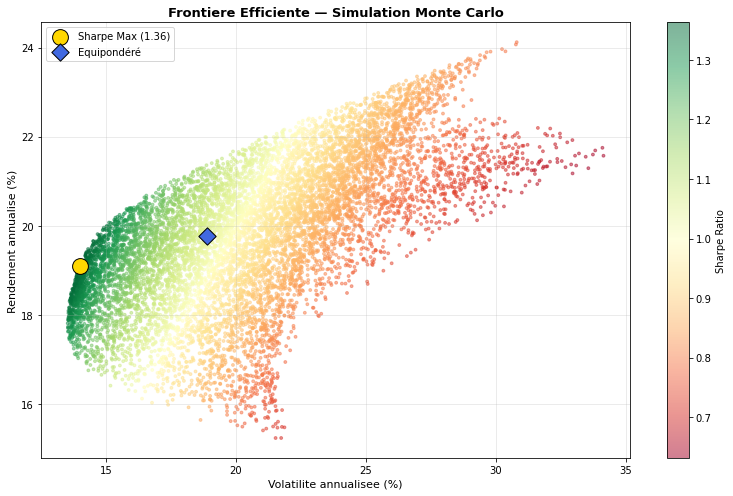

In [16]:
fig, ax = plt.subplots(figsize=(11, 7))

# Nuage de points (couleur = Sharpe Ratio)
sc = ax.scatter(
    df_sim['Volatilite'] * 100,
    df_sim['Rendement'] * 100,
    c=df_sim['Sharpe'], cmap='RdYlGn',
    alpha=0.5, s=8
)
plt.colorbar(sc, ax=ax, label='Sharpe Ratio')

# Portefeuille optimal
ax.scatter(
    port_optimal['Volatilite'] * 100,
    port_optimal['Rendement'] * 100,
    color='gold', edgecolors='black', s=250,
    zorder=5, label=f'Sharpe Max ({port_optimal["Sharpe"]:.2f})'
)

# Portefeuille equipondere
ax.scatter(sig_port*100, mu_port*100,
           color='royalblue', edgecolors='black', s=150, marker='D',
           zorder=5, label='Equipondéré')

ax.set_xlabel('Volatilite annualisee (%)', fontsize=11)
ax.set_ylabel('Rendement annualise (%)', fontsize=11)
ax.set_title('Frontiere Efficiente — Simulation Monte Carlo',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()